In [955]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from numpy import pi, sin, cos, exp, sum, min, max, sqrt
from tqdm import trange
from scipy import constants
import datetime

def psi_func(x,n_psi=1,L=1):
    return sin(pi*n_psi*x/L)
    #return sin(pi*n_psi*x/L)*exp( -(x-L/2) ** 2 / (2*.1**2))

In [ ]:
n_modes = 5     
n_points = 100
L = 1
n_psi = 2

psi_grid = np.linspace(0,L,n_points)
phi_grid = np.zeros(n_points-1)
for i in range(n_points-1):
    phi_grid[i] = (psi_grid[i+1] + psi_grid[i] )/2

psi = sin(n_psi*pi*psi_grid/L)
phi = np.zeros(n_points-1)
Q = np.abs(psi)**2 * (L/n_points)# * (L/(n_points-1))
Q = Q/np.sum(Q)


for i in range(n_points-1): #iterate over phi_grid
        phi[i] = np.sum( Q * np.abs(phi_grid[i]-psi_grid)**(-1) )

plt.plot(phi_grid,phi,color='blue',label=r'$\phi$')
plt.legend()
plt.show()

plt.plot(psi_grid,Q,color='orange',label=r'$Q$')
plt.legend()
plt.show()

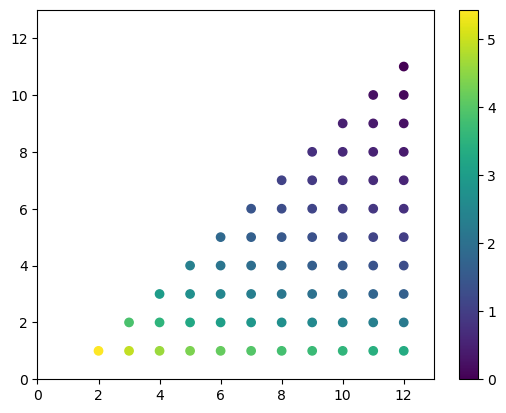

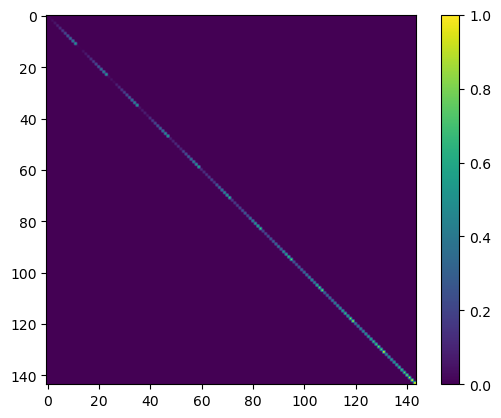

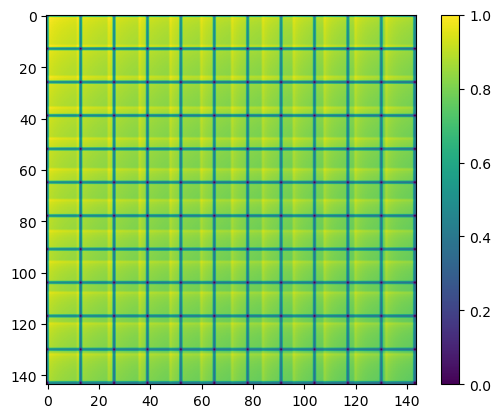

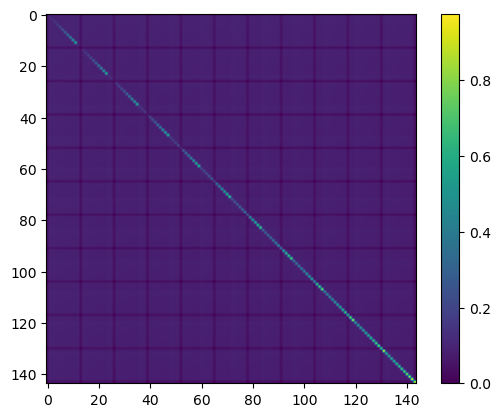

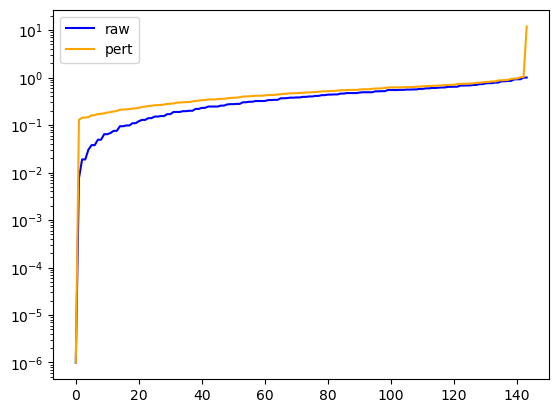

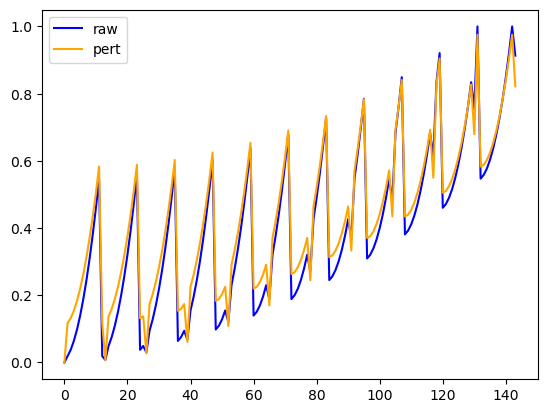

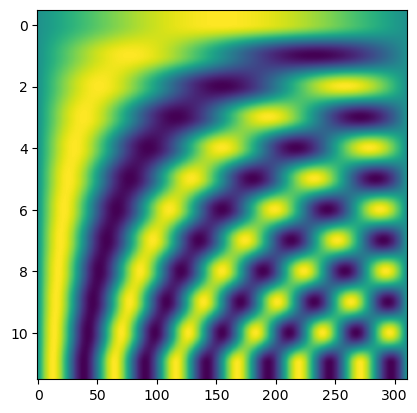

In [2]:
n_modes = 12
n_points = 311
L = 1

psi_grid = np.linspace(0,L,n_points)
phi_grid = np.zeros(n_points-1)
phi = np.zeros(n_points-1)

for i in range(n_points-1):
    phi_grid[i] = (psi_grid[i+1] + psi_grid[i] )/2

index_array = np.arange(n_modes) + 1

mat_elem = np.zeros([n_modes,n_modes])
box_energies = np.zeros([n_modes,n_modes])

for i_left in range(n_modes):
    for i_right in range(n_modes):
        if i_left != i_right:
            psi_left = psi_func(psi_grid,n_psi=index_array[i_left],L=L)
            Q_left = np.abs(psi_left)**2
            Q_left = Q_left/sum(Q_left)
            for i in range(n_points-1): #iterate over phi_grid
                phi[i] = np.sum( Q_left * np.abs(phi_grid[i]-psi_grid)**(-1) )
            phi = phi-min(phi)
            psi_right = psi_func(phi_grid,n_psi=index_array[i_right],L=L)
            Q_right = np.abs(psi_right)**2
            Q_right = Q_right/sum(Q_right)
            mat_elem[i_left,i_right] = sum( phi * Q_right )
            box_energies[i_left,i_right] = index_array[i_left]**2 + index_array[i_right]**2

for i in range(n_modes):
    box_energies[i,i] = 2*i**2


mat_elem = (mat_elem + mat_elem.T) #symmetrize

#plt.imshow(mat_elem)
#plt.colorbar()
#plt.show()

index_l, index_r, mode_l, mode_r, value = [], [], [], [], []

for i in range(n_modes): #find all lower triangle indices
    for j in range(n_modes):
        if index_array[j] < index_array[i]:
            index_l.append(i)
            index_r.append(j)
            value.append(mat_elem[i,j])
            
mode_l, mode_r = index_array[index_l], index_array[index_r]
value = mat_elem[index_l,index_r]
value = value - min(value)

plt.scatter(mode_l,mode_r,c=value)
plt.xlim([0,index_array.max()+1])
plt.ylim([0,index_array.max()+1])
plt.colorbar()
plt.show()

p_val = 0.1


big_H = np.zeros([n_modes**2,n_modes**2])
big_box_energies = np.zeros([n_modes**2,n_modes**2])
big_mat_elem = np.zeros([n_modes**2,n_modes**2])
for il in range(n_modes**2):
    #print(f"i_eff:{il_eff}, j_eff:{jl_eff}")
    for ir in range(n_modes**2):
        #i_eff = np.mod(i,n_modes)
        il_eff = il % n_modes
        jl_eff = int(np.floor(il/n_modes))
        ir_eff = ir % n_modes
        jr_eff = int(np.floor(ir/n_modes))
        if il == ir:
            big_box_energies[il,ir] = box_energies[il_eff,jl_eff] + box_energies[ir_eff,jr_eff]
        big_mat_elem[il,ir] = mat_elem[il_eff,jl_eff] + mat_elem[ir_eff,jr_eff]

big_box_energies = big_box_energies/np.abs(big_box_energies).max()
big_mat_elem = big_mat_elem/np.abs(big_mat_elem).max()
big_H = (1-p_val)*big_box_energies + p_val*big_mat_elem

plt.imshow(big_box_energies)
plt.colorbar()
plt.show()

plt.imshow(big_mat_elem)
plt.colorbar()
plt.show()

plt.imshow(big_H)
plt.colorbar()
plt.show()

val_pert, vec_pert = np.linalg.eigh(big_H)
val, vec = np.linalg.eigh(big_box_energies)

plt.plot(val-val.min()+1e-6,color='blue',label='raw')
plt.plot(val_pert-val_pert.min()+1e-6,color='orange',label='pert')
plt.yscale('log')
plt.legend()
plt.show()

pert_energies = np.zeros(n_modes**2)
raw_energies = np.zeros(n_modes**2)

for i in range(n_modes**2):
    tvec = np.zeros(n_modes**2)
    tvec[i] = 1
    pert_energies[i] = tvec@big_H@tvec
    raw_energies[i] = tvec@big_box_energies@tvec

plt.plot(raw_energies,color='blue',label='raw')
plt.plot(pert_energies,color='orange',label='pert')
plt.legend()
plt.show()

psi_big = np.zeros([n_modes,n_points])

for i in range(n_modes):
    psi_big[i,:] = psi_func(psi_grid,n_psi=index_array[i],L=L)

plt.imshow(psi_big,aspect=n_points/n_modes)

***QM*** ***!REWRITE!!!***

So we have an inner product $M_{i,j}$ that gives the Coulomb perturbation energy for states $\ket{\psi_i}$ and $\ket{\psi_j}$, where $\Big\{\psi_j \propto \sin(\pi n /L), n\in \mathbb{N}_{>0}\Big\}$ form a basis of the 1-particle Hilbert space up to normalization. 

The two-particle Hilbert space $\mathcal{H}_2$ is the Kronecker product over the 1-particle Hilbert spaces $\mathcal{H}_1$ and has a basis $\ket{i,j} = \Big(\ket{\psi_i} \otimes \ket{\psi_j} \pm \ket{\psi_j} \otimes \ket{\psi_i}\Big)/\sqrt{2}$. The unperturbedHamiltonian over this combined space is

\begin{equation}
\mathbb{H}_{un} = \mathbb{H}\otimes\mathbb{I} + \mathbb{I}\otimes\mathbb{H}
\end{equation}

Knowing the potential, this becomes:
\begin{equation}
\mathbb{H}_{un}\ket{i,j} = \Big(\mathbb{H}\otimes\mathbb{I} + \mathbb{I}\otimes\mathbb{H}\Big)\ket{i,j} = (i^2 + j^2)\ket{i,j}
\end{equation}

The interation term $\mathbb{H}_{in}$ gives the energy shift from $\ket{\psi_i}$'s electric potential acting on $\ket{\psi_j}$. In the continuous limit, this is symmetric, but in general this is not true for the staggered-grid discrete approximation away from this limit.

Assuming symmetry (or forced symmetrization by $\mathbb{H}_{in}' = \Big(\mathbb{H}_{in} + \mathbb{H}_{in}^T\Big)/2$),

The interaction energy for a state $\ket{i,j}$ is 

\begin{equation}
\mathbb{H}'\ket{i,j} =  \mathbb{H}'\Big(\ket{\psi_i} \otimes \ket{\psi_j} \pm \ket{\psi_j} \otimes \ket{\psi_i}\Big)/\sqrt{2} = \mathbb{H}_{i,j}'\ket{\psi_i} \otimes \ket{\psi_j} \pm \mathbb{H}_{j,i}'\ket{\psi_j} \otimes \ket{\psi_i} = 2\mathbb{H}_{i,j}\ket{i,j}
\end{equation}

The full Hamiltonian in $\mathcal{H}_2$ is $\mathbb{H}_{tot} = \mathbb{H}_{un} + \lambda\mathbb{H}_{i,j}'$, which acts on a state $\ket{i,j}$ as:

\begin{equation}
\mathbb{H}_{tot}\ket{i,j} = \Bigg( (i^2 + j^2) + 2\mathbb{H}_{i,j}' \Bigg)\ket{i,j}
\end{equation}

In [6]:
ind_start = 0
ind_width = 0

plot_raw = 1
plot_pert = 1
plot_diff = 1

for vec_index in range(ind_start, ind_start+ind_width):
    out_wave_raw = np.zeros(n_points)
    out_wave_pert = np.zeros(n_points)
    
    for i in range(n_modes**2):
        i_eff = i % n_modes
        j_eff = int(np.floor(i/n_modes))
        out_wave_raw += vec[vec_index,i]**2 * (np.abs(psi_big[i_eff,:])**2 + np.abs(psi_big[j_eff,:])**2 )
        out_wave_pert += vec_pert[vec_index,i]**2 * (np.abs(psi_big[i_eff,:])**2 + np.abs(psi_big[j_eff,:])**2 )
    if plot_raw == 1:
        plt.plot(sqrt(out_wave_raw),color='blue')
    if plot_pert == 1:
        plt.plot(sqrt(out_wave_pert),color='orange')
    if plot_diff == 1:
        plt.plot(sqrt( abs(out_wave_pert - out_wave_raw) ),color='green')

In [ ]:
vec_index = 4


out_wave = np.zeros(n_points)

for i in range(n_modes**2):
    i_eff = i % n_modes
    j_eff = int(np.floor(i/n_modes))
    out_wave += vec[vec_index,i]**2 * (np.abs(psi_big[i_eff,:])**2 + np.abs(psi_big[j_eff,:])**2 )

plt.plot(sqrt(out_wave)/sum(sqrt(out_wave)))

In [ ]:
plt.imshow((np.abs(vec_pert)+1e-3))
plt.colorbar()

In [ ]:
plt.imshow((np.abs(vec)+1e-3))
plt.colorbar()

In [ ]:
plt.imshow((np.abs(vec_pert-vec)+1e-3))
plt.colorbar()

In [ ]:
plt.plot(abs(vec_pert[:,0])**2)

In [ ]:
pert_energies = np.zeros(n_modes**2)
raw_energies = np.zeros(n_modes**2)

for i in range(n_modes**2):
    tvec = np.zeros(n_modes**2)
    tvec[i] = 1
    pert_energies[i] = tvec@big_H@tvec
    raw_energies[i] = tvec@big_box_energies@tvec

In [ ]:
plt.plot(raw_energies)
plt.plot(pert_energies)

In [ ]:
for i in range(10):
    plt.plot(vec_pert[:,i],label=f'{i}')

In [ ]:
plt.plot(val_pert-val_pert.min()+1e-1)
plt.yscale('log')

In [ ]:
val_pert.min()

In [315]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from numpy import pi, sin, cos, exp, sum, min, max, sqrt
from tqdm import trange
from scipy import constants


def generate_H_matrix(n_points,potential_function,bc='periodic',L=1,bloch_phase=1.,include_potential=True,hbar=1,mass=1):
    h = L/n_points
    
    diag = -2*np.ones(n_points)/( h**2 )
    off_diag = np.ones(n_points-1)/(h**2)
    offsets = [-1, 0, 1]
    laplacian = sp.diags([off_diag,diag,off_diag],offsets,dtype='complex128').tolil()
    if bc == 'periodic':
        laplacian[0, n_points- 1] = 1.0 / (h**2)
        laplacian[n_points - 1, 0] = 1.0 / (h**2)
    if bc == 'bloch':
        bloch_phase = exp(-1J*bloch_phase)
        laplacian[0, n_points- 1] = bloch_phase / (h**2)
        laplacian[n_points - 1, 0] = np.conjugate(bloch_phase) / (h**2)
    laplacian = laplacian.tocsr()
    prefix = hbar**2/(2*mass)
    out = -prefix*laplacian
    if include_potential == True:
        grid = np.linspace(0,L,n_points,endpoint=False)
        V_arr = potential_function(grid)
        V_mat = sp.diags(diagonals=[V_arr],offsets=[0],dtype='complex128').tocsr()
        out += V_mat
    return out


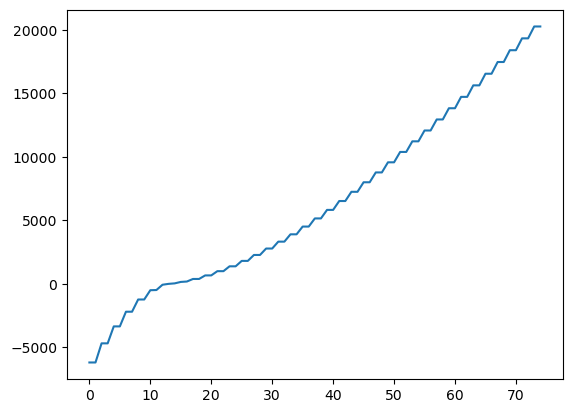

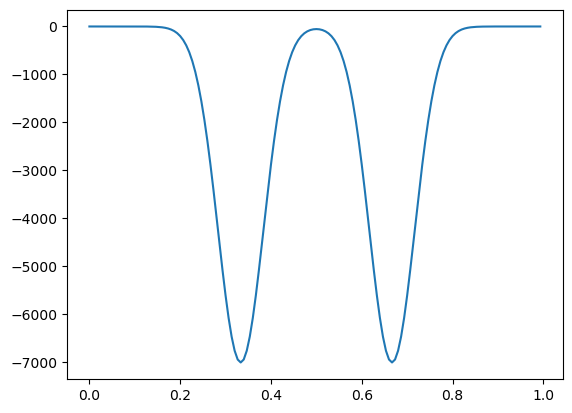

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


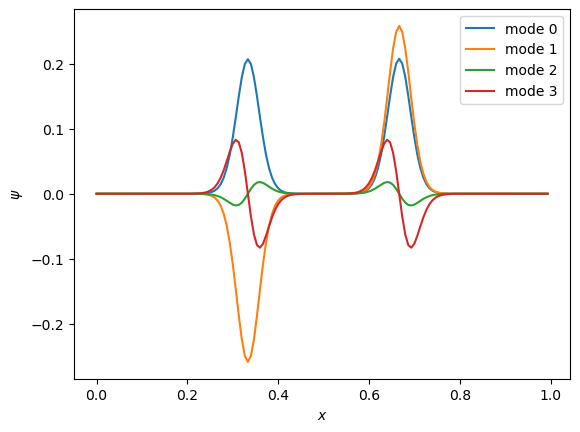

In [316]:
n_points = 150
plot_modes_start = 0
n_plot_modes = 4

def V(x):
    #return sin(1*pi*x)
    #return 10000*exp(-(x-.5)**2/(2*.1**2))
    sigma = .05
    #return -2000*( exp(-(x-.25)**2 / (2*sigma**2)) + exp(-(x-.5)**2 / (2*sigma**2)) + exp(-(x-.75)**2 / (2*sigma**2)) )
    return -7000*( exp(-(x-1/3)**2 / (2*sigma**2)) + exp(-(x-2/3)**2 / (2*sigma**2)) ) 

def V0(x):
    return x*0

#H = generate_H_matrix(n_points,V)
H = generate_H_matrix(n_points,V,bloch_phase=pi)


k = np.max([int(n_points/2),20])
#plt.imshow(H.toarray())

val, vec = spla.eigsh(H,k=int(n_points/2),which='SA')

order = np.argsort(val)
val = val[order]
vec = vec[:, order]

plt.plot(val)
plt.show()

grid = np.linspace(0,1,n_points,endpoint=False)
plt.plot(grid,V(grid))
plt.show()

for i in range(plot_modes_start,plot_modes_start + n_plot_modes):
    plt.plot(grid,vec[:,i],label=f'mode {i}')
plt.legend()
plt.xlabel(r'$x$')
plt.ylabel(r'$\psi$')
plt.show()

In [153]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# paste or import your generate_H_matrix here
# from your_module import generate_H_matrix

def check_H_and_eigs(H, k=6):
    # Hermiticity check (Frobenius norm of H - H^H)
    Hc_diff = (H - H.getH()).tocoo()
    herm_norm = np.sqrt((abs(Hc_diff.data)**2).sum())
    print("Hermiticity norm ||H - H^H||_F =", herm_norm)

    # compute a few eigenpairs
    eigvals, eigvecs = spla.eigsh(H, k=k, which='SA')
    order = np.argsort(eigvals)
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    print("Eigenvalues (lowest ->):", eigvals)

    # Inspect first eigenvector
    psi0 = eigvecs[:, 0]
    psi0 = psi0 / np.linalg.norm(psi0)  # normalized 2-norm

    print("psi0[0:16] (first 16 components):")
    print(np.round(psi0[:16], 6))
    print("psi0[0] - psi0[-1] (periodicity check) =", psi0[0] - psi0[-1])

    # check if psi0 is approximately constant (for V = const)
    const_err = np.linalg.norm(psi0 - psi0.mean())
    print("Norm of (psi0 - mean) =", const_err)

    return eigvals, eigvecs

# Example usage:
n_points = 200
L = 1.0
def V_const(x): return -1.0 * np.ones_like(x)

# Build H with a corrected grid inside generate_H_matrix; if you did not change yours,
# make sure generate_H_matrix uses x = np.arange(n_points)*h, not linspace with endpoint=True.
H = generate_H_matrix(n_points, V_const, bc='periodic', L=L, include_potential=True, hbar=1., mass=1.)
eigvals, eigvecs = check_H_and_eigs(H, k=6)


Hermiticity norm ||H - H^H||_F = 0.0
Eigenvalues (lowest ->): [ -1.          18.73758537  18.73758537  77.93086287  77.93086287
 176.52141588]
psi0[0:16] (first 16 components):
[-0.070711 -0.070711 -0.070711 -0.070711 -0.070711 -0.070711 -0.070711
 -0.070711 -0.070711 -0.070711 -0.070711 -0.070711 -0.070711 -0.070711
 -0.070711 -0.070711]
psi0[0] - psi0[-1] (periodicity check) = -6.938893903907228e-17
Norm of (psi0 - mean) = 3.221432443230455e-14


100%|██████████| 12/12 [01:17<00:00,  6.49s/it]


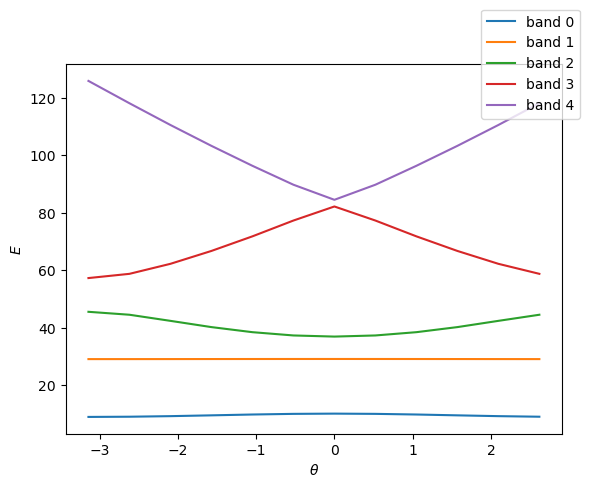

In [326]:
n_points = 150
n_points_theta = 12

n_bands = 5

k = np.max([int(n_points/2),20])



def V(x):
    #return 0 * x - 100
    #return sin(1*pi*x)
    return -50*cos(2*pi*x)
    #return 10000*exp(-(x-.5)**2/(2*.1**2))
    sigma = .05
    #return -2000*( exp(-(x-.25)**2 / (2*sigma**2)) + exp(-(x-.5)**2 / (2*sigma**2)) + exp(-(x-.75)**2 / (2*sigma**2)) )
    #return -100*( exp(-(x-1/3)**2 / (2*sigma**2)) + exp(-(x-2/3)**2 / (2*sigma**2)) ) 

def V0(x):
    return x*0

val_block = np.zeros([k,n_points_theta],dtype='float64')
thetas = np.linspace(0,2*pi,n_points_theta,endpoint=False) - pi
#H = generate_H_matrix(n_points,V)
for j in trange(n_points_theta):
    theta = thetas[j]
    H = generate_H_matrix(n_points,V,bloch_phase=theta,bc='bloch')

    

    val, vec = spla.eigsh(H,k=k,which='SA')
    val, vec = np.abs(val), np.abs(vec)
    order = np.argsort(val)
    val = val[order]
    vec = vec[:, order]
    val_block[:,j] = val
    #plt.plot(val[:5],label=r'$\theta$ = ' + f'{theta:.2f}')
#plt.legend()
#plt.show()



for i in range(n_bands):
    plt.plot(thetas,val_block[i,:],label=f'band {i}')
plt.legend(loc='right', bbox_to_anchor=(1.05, 1))
plt.xlabel(r'$\theta$')
plt.ylabel(r'$E$')
plt.show()


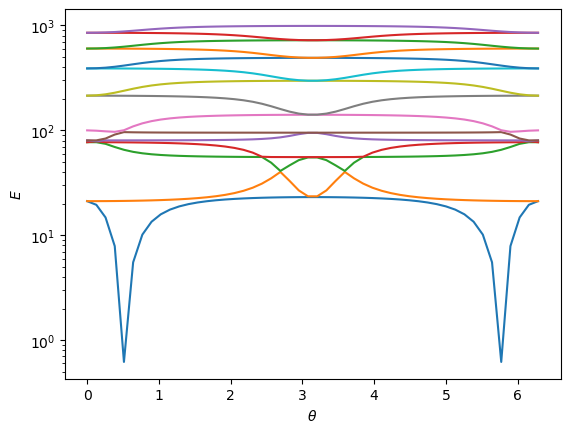

In [305]:
n_bands = 15

for i in range(n_bands):
    plt.plot(thetas,val_block[i,:],label=f'band {i}')
#plt.legend(loc='right', bbox_to_anchor=(1.05, 1))
plt.xlabel(r'$\theta$')
plt.ylabel(r'$E$')
plt.yscale('log')
plt.show()

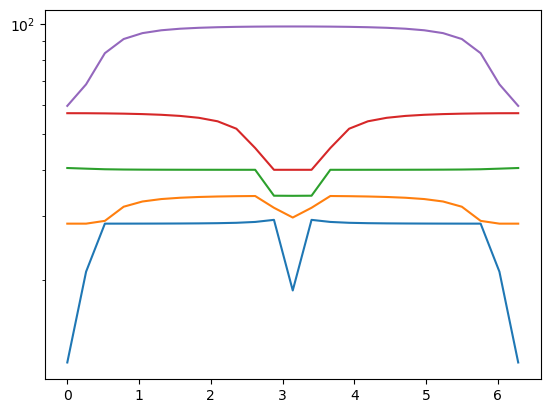

In [285]:
n_bands = 5
for i in range(n_bands):
    plt.plot(thetas,val_block[i,:])
plt.yscale('log')

In [230]:
H - H.conjugate()

<100x100 sparse matrix of type '<class 'numpy.float64'>'
	with 0 stored elements in Compressed Sparse Row format>

In [187]:
vec[:,0].mean()/vec[:,0].std()

-7157164051679.015

In [ ]:
H0 = np.array([[1,0],[0,-1]])

In [330]:
H0

array([[ 1,  0],
       [ 0, -1]])

In [334]:
I0 = np.eye(2)

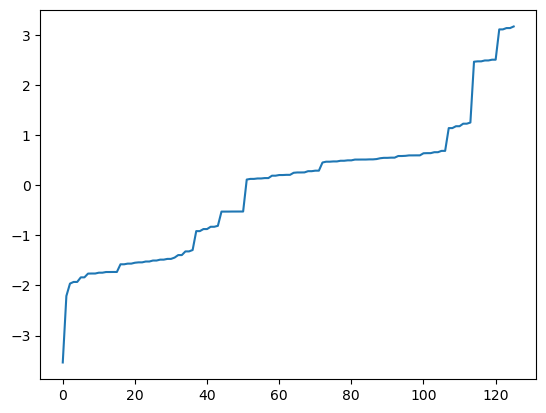

In [549]:
from functools import reduce

n_sites = 7
field = -.1
hop = -.5
hop_3 = .1
hop_4 = .1
k=126
bc = 'periodic'
dtype = 'complex128'
H0 = sp.csr_matrix( np.array([[1,0],[0,-1]],dtype = dtype) )
I0 = sp.csr_matrix( np.eye(2) )
sigma_x = sp.csr_matrix( np.array([[0,1],[1,0]],dtype=dtype) )

H_chain = sp.csr_matrix((2**n_sites, 2**n_sites), dtype=dtype)

def kron_N(lst):
    """Tensor product of a list of matrices."""
    return reduce(sp.kron, lst)

for i in range(n_sites): #site-level Hamiltonian
    factors = [I0] * n_sites
    factors[i] = H0
    H_chain += field*kron_N(factors)

for i in range(n_sites-1): #pair interaction
    factors = [I0] * n_sites
    factors[i], factors[i+1] = sigma_x, sigma_x
    H_chain += hop*kron_N(factors)

if bc == 'periodic':
    factors = [I0] * n_sites
    factors[0], factors[-1] = sigma_x, sigma_x
    H_chain += hop*kron_N(factors)

if n_sites > 3:
    if bc == 'periodic':
        for i in range(n_sites):
            factors = [I0] * n_sites
            factors[i % n_sites], factors[(i+1) % n_sites], factors[(i+2) % n_sites] = sigma_x, sigma_x, sigma_x
            H_chain += hop_3*kron_N(factors)

if n_sites > 4:
    if bc == 'periodic':
        for i in range(n_sites):
            factors = [I0] * n_sites
            factors[i % n_sites], factors[(i+1) % n_sites], factors[(i+2) % n_sites], factors[(i+3) % n_sites] = sigma_x, sigma_x, sigma_x, sigma_x
            H_chain += hop_4*kron_N(factors)

val, vec = spla.eigsh(H_chain,which='SA',k=k)
order = np.argsort(val)
val = val[order]
vec = vec[:, order]
plt.plot(val)

In [495]:
import numpy as np

def print_spin_vector_topk(
        vec,
        k=10,
        threshold=1e-6,
        normalize=True,
        latex=False,
        show_barchart=True,
        bar_width=40
    ):
    N = int(np.log2(len(vec)))

    # ---- Collect significant entries into an explicit list ----
    entries = []
    for idx, amp in enumerate(vec):
        if abs(amp) < threshold:
            continue
        
        bits = format(idx, f'0{N}b')
        config = ''.join('↑' if b=='1' else '↓' for b in bits)
        braket = f"|{config}⟩"

        prob = float(abs(amp)**2)
        phase = float(np.angle(amp))

        entries.append((braket, prob, phase))

    if len(entries) == 0:
        print("No entries above threshold.")
        return
    
    # ---- Convert to list explicitly (no generators) ----
    entries = list(entries)

    # ---- Sort ----
    entries.sort(key=lambda x: x[1], reverse=True)
    entries = entries[:k]

    # ---- Normalize probabilities ----
    if normalize:
        probs = [p for (_, p, _) in entries]  # explicit list
        total = sum(probs)
        if total > 0:
            entries = [(b, p / total, ph) for (b, p, ph) in entries]

    # ---- LaTeX output ----
    if latex:
        lines = []
        for braket, prob, phase in entries:
            phase_pi = phase / np.pi
            lines.append(
                f"{prob:.6f}\\, e^{{i({phase_pi:.6f}\\pi)}}\\,{braket}"
            )
        print("$\n" + " \\\\\n".join(lines) + "\n$")
        return

    # ---- Text output ----
    print(f"Top {k} components:\n")

    probs = [p for (_, p, _) in entries]   # explicit list
    max_prob = max(probs)

    for braket, prob, phase in entries:
        phase_pi = phase / np.pi
        bar = ""
        if show_barchart:
            bar_len = int(bar_width * (prob / max_prob))
            bar = " |" + "█" * bar_len

        print(
            f"{braket:>10}   "
            f"prob = {prob:.2f}   "
            f"phase = {phase:+.2f} rad ({phase_pi:+.2f} π)"
            f"{bar}"
        )



print_spin_vector_topk(vec[:,2])

Top 10 components:

 |↓↓↓↓↑↓↓⟩   prob = 0.27   phase = -1.39 rad (-0.44 π) |████████████████████████████████████████
 |↓↓↓↑↓↓↓⟩   prob = 0.25   phase = +1.84 rad (+0.58 π) |█████████████████████████████████████
 |↓↓↓↓↓↑↓⟩   prob = 0.19   phase = +1.66 rad (+0.53 π) |████████████████████████████
 |↓↓↑↓↓↓↓⟩   prob = 0.15   phase = -1.20 rad (-0.38 π) |██████████████████████
 |↓↓↓↓↓↓↑⟩   prob = 0.07   phase = -1.65 rad (-0.53 π) |███████████
 |↓↑↓↓↓↓↓⟩   prob = 0.04   phase = +2.19 rad (+0.70 π) |██████
 |↑↓↓↓↓↓↓⟩   prob = 0.01   phase = +0.60 rad (+0.19 π) |█
 |↓↓↓↑↑↑↓⟩   prob = 0.00   phase = -1.39 rad (-0.44 π) |
 |↓↓↑↑↑↓↓⟩   prob = 0.00   phase = +1.84 rad (+0.58 π) |
 |↓↓↓↓↑↑↑⟩   prob = 0.00   phase = +1.66 rad (+0.53 π) |


In [ ]:
import numpy as np
import scipy.sparse as sp
from functools import reduce

# Pauli Z
sigma_z = sp.csr_matrix([[1, 0],
                         [0, -1]])

def magnetization_operator(N):
    """Construct total Mz operator (sparse) for N spins"""
    Id = sp.identity(2, format='csr')
    sigma_z:sp.csr_matrix = sp.csr_matrix( np.array([[1,0],[0,-1]],dtype = dtype) )

    factors = []
    for i in range(N):
        ops = [Id]*N
        ops[i] = sigma_z
        factor = reduce(sp.kron, ops)
        factors.append(factor)
    return sum(factors)

def expectation_magnetization(psi, per_spin=True):
    """
    psi: numpy array (state vector, length 2^N)
    per_spin: divide by N to get magnetization per spin
    """
    N = int(np.log2(len(psi)))
    Mz = magnetization_operator(N)
    exp_val = np.vdot(psi, Mz.dot(psi)).real  # <psi|Mz|psi>
    if per_spin:
        return exp_val / N
    return exp_val

def expectation_energy(psi, Hamil, per_spin=True):
    """
    psi: numpy array (state vector, length 2^N)
    per_spin: divide by N to get magnetization per spin
    """
    N = int(np.log2(len(psi)))
    exp_val = np.vdot(psi, Hamil.dot(psi)).real  # <psi|Mz|psi>
    if per_spin:
        return exp_val / N
    return exp_val


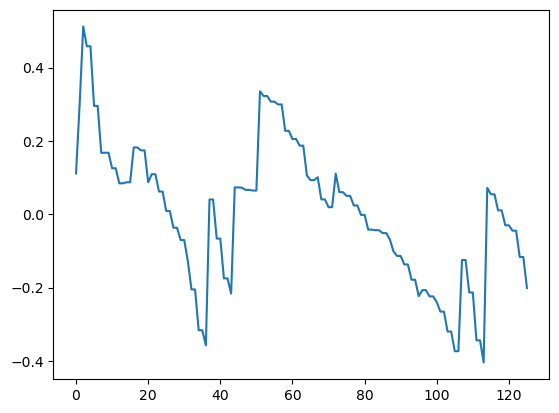

In [550]:
mags = np.zeros(k)

for i in range(k):
    mags[i] = expectation_magnetization(vec[:,i])

plt.plot(mags)

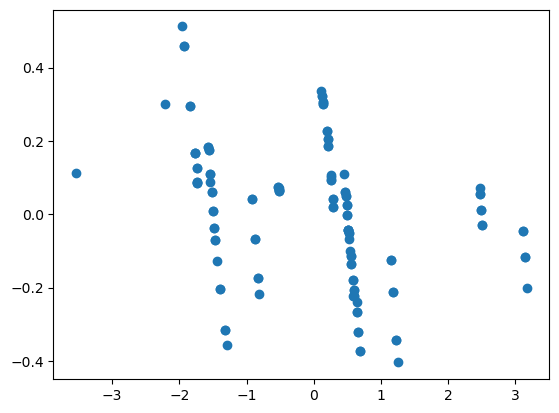

In [551]:
plt.scatter(val,mags)

In [ ]:
val

array([-7.01751094, -5.19563698, -5.19563698, -5.05231806, -5.05231806,
       -4.88706694, -4.88706694, -4.81751099, -3.33570113, -3.33570113,
       -3.25389132, -3.16372986, -3.16372986, -3.08192005, -3.08192005,
       -3.08192005, -3.08192005, -3.03559089, -3.03559089, -2.95378109,
       -2.95378109, -2.95378109, -2.95378109, -2.90994877, -2.78180981,
       -2.78180981, -2.78180981, -2.78180981, -2.65367085, -1.40857004,
       -1.40857004, -1.26525112, -1.26525112, -1.24331892, -1.24331892,
       -1.17376297, -1.1       , -1.1       , -1.1       , -1.1       ,
       -1.1       , -1.1       , -1.1       , -1.1       , -1.03044405,
       -1.03044405, -1.03044405, -1.03044405, -0.95668108, -0.95668108,
       -0.93474888, -0.93474888, -0.88712513, -0.86519293, -0.86519293,
       -0.86519293, -0.86519293, -0.79142996, -0.79142996, -0.72187401,
       -0.72187401, -0.72187401, -0.72187401, -0.55662289,  0.59988976,
        0.59988976,  0.72802872,  0.72802872,  0.77186104,  0.77

100%|██████████| 20/20 [00:06<00:00,  3.05it/s]


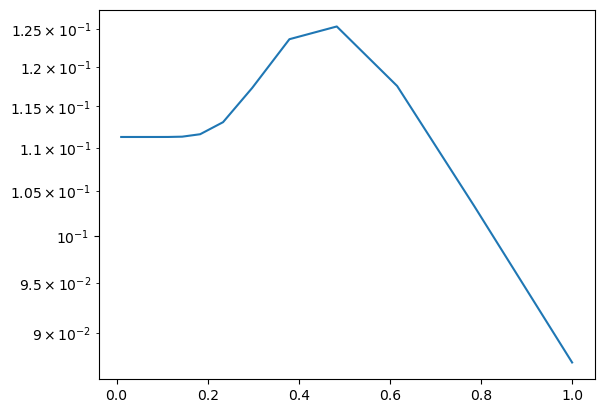

In [552]:
n_temps = 20

mag_thermal_arr = np.zeros(n_temps)
temp_power_array = np.linspace(-2,0,n_temps)
temp_array = 10**temp_power_array

for j in trange(n_temps):
    temp = temp_array[j]
    weights = exp(-val/temp)
    weights = weights/np.sum(weights)

    mag_thermal = 0
    for i in range(k):
        mag_thermal += weights[i]*expectation_magnetization(vec[:,i])
    mag_thermal_arr[j] = mag_thermal

plt.plot(temp_array,mag_thermal_arr)
plt.yscale('log')

100%|██████████| 50/50 [04:32<00:00,  5.44s/it]

complete!


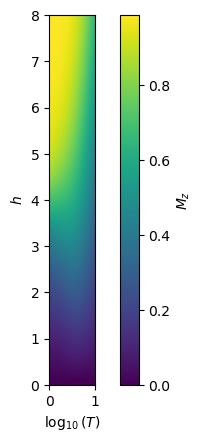

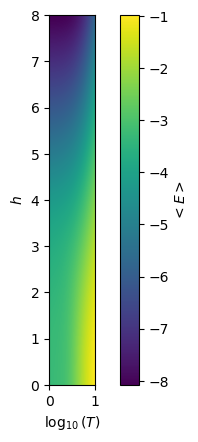

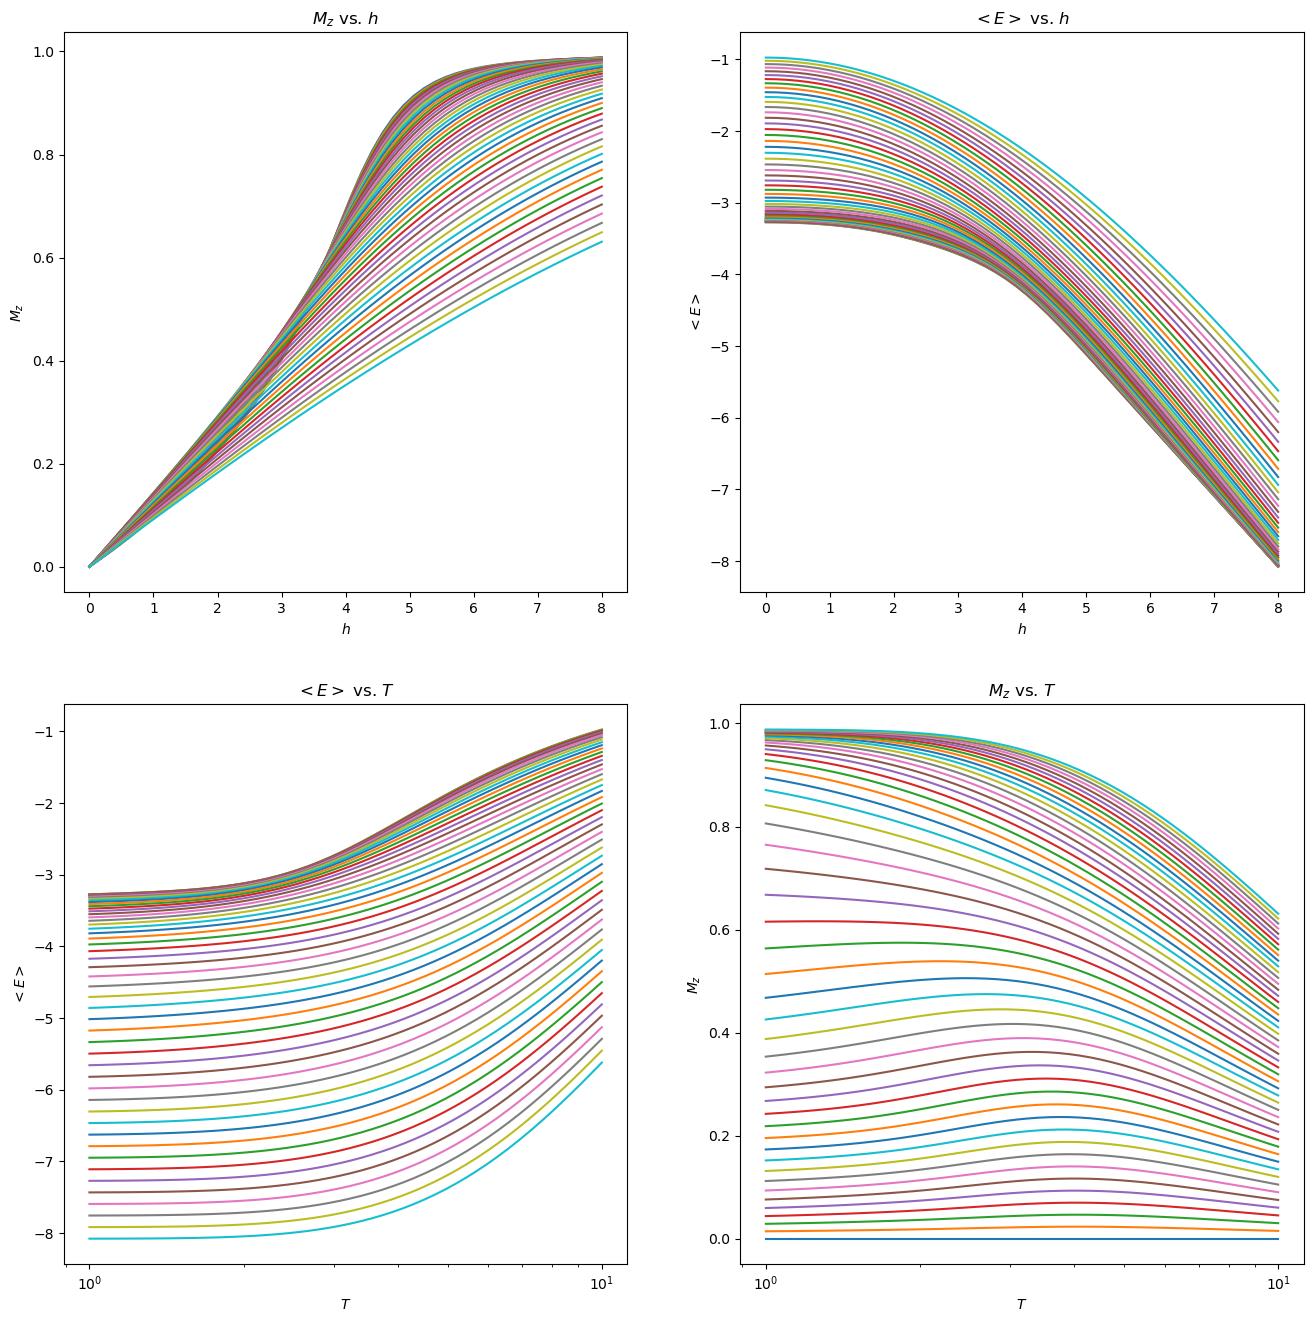

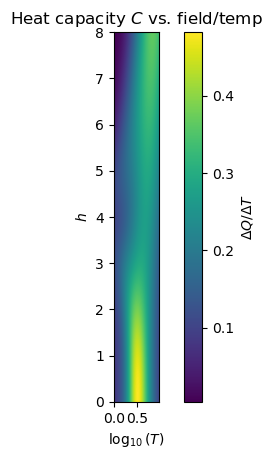

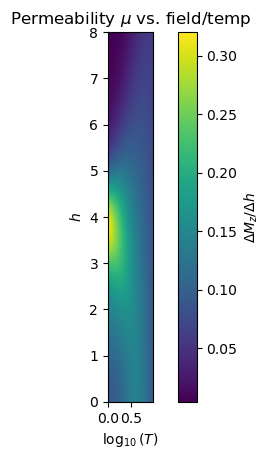

In [ ]:
from functools import reduce

n_field_strengths:int = 50
field_min:float = 0
field_max:float = 8

n_temps:int = 50
temp_power_array:np.ndarray = np.linspace(-0.0,1.0,n_temps,dtype='float64')
temp_array:np.ndarray = 10**temp_power_array

field = np.linspace(field_min,field_max,n_field_strengths,dtype='float64')

n_sites:int = 6
hop_x:float= -1.5
hop_y:float = -1*2.5
hop_3:float =  -1*0.5
hop_4:float = -1*0.5
hop_xy:float = -1*0.5
hop_yx:float = -1*0.5

k:int = 2**n_sites - 2
bc:str = 'periodic'
dtype:str = 'complex128'
H0 = sp.csr_matrix( np.array([[1,0],[0,-1]],dtype = dtype) )
I0 = sp.csr_matrix( np.eye(2) )
sigma_x = sp.csr_matrix( np.array([[0,1],[1,0]],dtype=dtype) )
sigma_y = sp.csr_matrix( np.array([[0,-1J],[1J,0]],dtype=dtype) )

mag_arr = np.zeros([n_field_strengths,n_temps],dtype='float64')
energy_arr = np.zeros([n_field_strengths,n_temps],dtype='float64')

def kron_N(lst):
    """Tensor product of a list of matrices."""
    return reduce(sp.kron, lst)

for field_index in trange(n_field_strengths):

    #### create Hamiltonian
    H_chain = sp.csr_matrix((2**n_sites, 2**n_sites), dtype=dtype)

    for i in range(n_sites): #site-level Hamiltonian
        factors = [I0] * n_sites
        factors[i] = H0
        H_chain += field[field_index]*kron_N(factors)

    for i in range(n_sites-1): #pair interaction
        factors = [I0] * n_sites
        factors[i], factors[i+1] = sigma_x, sigma_x
        H_chain += hop_x*kron_N(factors)
    
    for i in range(n_sites-1): #pair interaction
        factors = [I0] * n_sites
        factors[i], factors[i+1] = sigma_y, sigma_y
        H_chain += hop_y*kron_N(factors)

    if bc == 'periodic':
        factors = [I0] * n_sites
        factors[0], factors[-1] = sigma_x, sigma_x
        H_chain += hop_x*kron_N(factors)
        factors = [I0] * n_sites
        factors[0], factors[-1] = sigma_y, sigma_y
        H_chain += hop_y*kron_N(factors)

    if n_sites > 3:
        if bc == 'periodic':
            for i in range(n_sites):
                factors = [I0] * n_sites
                factors[i % n_sites], factors[(i+1) % n_sites], factors[(i+2) % n_sites] = sigma_x, sigma_x, sigma_x
                H_chain += hop_3*kron_N(factors)

    if n_sites > 4:
        if bc == 'periodic':
            for i in range(n_sites):
                factors = [I0] * n_sites
                factors[i % n_sites], factors[(i+1) % n_sites], factors[(i+2) % n_sites], factors[(i+3) % n_sites] = sigma_x, sigma_x, sigma_x, sigma_x
                H_chain += hop_4*kron_N(factors)

    if bc == 'periodic':
        for i in range(n_sites):
            factors = [I0] * n_sites
            factors[i], factors[(i+1) % n_sites] = sigma_x, sigma_y
            H_chain += hop_xy*kron_N(factors)

    if bc == 'periodic':
        for i in range(n_sites):
            factors = [I0] * n_sites
            factors[i], factors[(i+1) % n_sites] = sigma_y, sigma_x
            H_chain += hop_xy*kron_N(factors)


    ##### calculate
    val, vec = spla.eigsh(H_chain,which='SA',k=k)
    order = np.argsort(val)
    val = val[order]
    vec = vec[:, order]

    mag_thermal_arr = np.zeros(n_temps)
    energy_thermal_arr = np.zeros(n_temps)

    for j in range(n_temps):
        temp = temp_array[j]
        weights = np.zeros(val.size,dtype=np.float64)
        weights[:] = exp(-(val-val.min())/temp)
        weight_prefactor = exp(-val.min()/temp)
        #weights[:] = exp(-(val)/temp)
        #print(np.sum(weights)) 
        weights = weights/np.sum(weights)

        mag_thermal = 0
        energy_thermal = 0
        for i in range(k):
            mag_thermal += -1*weights[i]*expectation_magnetization(vec[:,i])
            energy_thermal += weights[i]*( expectation_energy(vec[:,i],H_chain) )
        mag_thermal_arr[j] = mag_thermal
        energy_thermal_arr[j] = energy_thermal
    
    mag_arr[field_index,:] = mag_thermal_arr
    energy_arr[field_index,:] = energy_thermal_arr

print('complete!')
#magnetization vs. field/temp
plt.imshow(mag_arr,extent=(np.log10(temp_array.min()),np.log10(temp_array.max()),field.min(),field.max()),interpolation='bicubic',origin='lower')
plt.colorbar(label=r'$M_z$')
plt.xlabel(r'$\log_{10}(T)$')
plt.ylabel(r'$h$')
plt.show()

#energy vs. field/temp
plt.imshow(energy_arr,extent=(np.log10(temp_array.min()),np.log10(temp_array.max()),field.min(),field.max()),interpolation='bicubic',origin='lower')
plt.colorbar(label=r'$<E>$')
plt.xlabel(r'$\log_{10}(T)$')
plt.ylabel(r'$h$')
plt.show()

fig1, axs1 = plt.subplots(2,2,figsize=(16,16))
#magnetization vs. field
for i in range(n_temps):
    axs1[0,0].plot(field,mag_arr[:,i])
axs1[0,0].set_xlabel(r'$h$')
axs1[0,0].set_ylabel(r'$M_z$')
axs1[0,0].set_title(r'$M_z$ vs. $h$')

#energy vs. field
for i in range(n_temps):
    axs1[0,1].plot(field,energy_arr[:,i])
axs1[0,1].set_xlabel(r'$h$')
axs1[0,1].set_ylabel(r'$<E>$')
axs1[0,1].set_title(r'$<E>$ vs. $h$')

#energy vs. temp
for i in range(n_field_strengths):
    axs1[1,0].plot(temp_array,energy_arr[i,:])
axs1[1,0].set_xscale('log')
axs1[1,0].set_xlabel(r'$T$')
axs1[1,0].set_ylabel(r'$<E>$')
axs1[1,0].set_title(r'$<E>$ vs. $T$')


#magnetization vs. temp
for i in range(n_field_strengths):
    axs1[1,1].plot(temp_array,mag_arr[i,:])
axs1[1,1].set_xscale('log')
axs1[1,1].set_xlabel(r'$T$')
axs1[1,1].set_ylabel(r'$M_z$')
axs1[1,1].set_title(r'$M_z$ vs. $T$')

plt.show()


#heat capacity
heat_cap = np.zeros([n_field_strengths,n_temps-1])
for h in range(n_field_strengths):
    for t in range(n_temps-1):
        heat_cap[h,t] = (energy_arr[h,t+1] - energy_arr[h,t]) / (temp_array[t+1] - temp_array[t])

plt.imshow(heat_cap,extent=[np.log10(temp_array[:-1].min()),np.log10(temp_array[:-1].max()),field.min(),field.max()],aspect=n_field_strengths/n_temps,interpolation='bicubic',origin='lower')
plt.colorbar(label=r'$\Delta Q/\Delta T$')
plt.xlabel(r'$\log_{10}(T)$')
plt.ylabel(r'$h$')
plt.title(r'Heat capacity $C$ vs. field/temp')
plt.show()

#permeability
permeability = np.zeros([n_field_strengths-1,n_temps])
for h in range(n_field_strengths-1):
    for t in range(n_temps):
        permeability[h,t] = (mag_arr[h+1,t] - mag_arr[h,t]) / (field[h+1] - field[h])

plt.imshow(permeability,extent=[np.log10(temp_array[:-1].min()),np.log10(temp_array[:-1].max()),field.min(),field.max()],aspect=n_field_strengths/n_temps,interpolation='bicubic',origin='lower')
plt.colorbar(label=r'$\Delta M_z/\Delta h$')
plt.xlabel(r'$\log_{10}(T)$')
plt.ylabel(r'$h$')
plt.title(r'Permeability $\mu$ vs. field/temp')
plt.show()

In [1183]:
n_sites:int = 6
hop_x:float= -1.5
hop_y:float = -1*2.5
hop_3:float =  -1*0.5
hop_4:float = -1*0.5
hop_xy:float = -1*0.5
hop_yx:float = -1*0.5

def create_H_chain(n_sites:int,h:float,hop_x:float,hop_y:float=0.,hop_3:float=0.,hop_4:float=0.,hop_xy:float=0.,bc:str='periodic') -> sp.csr_matrix:
    """Takes number of qubits, coefficients for various terms, and boundary conditions. Returns a sp.csr_matrix representing the specified spin chain Hamiltonian.

    Parameters:
    h: I x ... I x sigma_z x I x ...
    hop_x: I x ... I x sigma_x x sigma_x x I x ...
    hop_y: I x ... I x sigma_y x sigma_y x I x ...
    hop_3: I x ... I x sigma_x x sigma_x x sigma_x x I x ...
    hop_4: I x ... I x sigma_x x sigma_x x sigma_x x sigma_x x I x ...
    hop_xy = I x ... I x (sigma_x + sigma_y) x (sigma _x + sigma_y) x I x ...
    bc: 'periodic' includes qubit_n <-> qubit_0 couplings
    """
    bc:str = 'periodic'
    dtype:str = 'complex128'
    sigma_z:sp.csr_matrix = sp.csr_matrix( np.array([[1,0],[0,-1]],dtype = dtype) )
    I0:sp.csr_matrix = sp.csr_matrix( np.eye(2) )
    sigma_x:sp.csr_matrix = sp.csr_matrix( np.array([[0,1],[1,0]],dtype=dtype) )
    sigma_y:sp.csr_matrix = sp.csr_matrix( np.array([[0,-1J],[1J,0]],dtype=dtype) )

    #### create Hamiltonian
    H_chain = sp.csr_matrix((2**n_sites, 2**n_sites), dtype=dtype)

    for i in range(n_sites): #site-level Hamiltonian
        factors = [I0] * n_sites
        factors[i] = sigma_z
        H_chain += h*kron_N(factors)

    for i in range(n_sites-1): #pair interaction
        factors = [I0] * n_sites
        factors[i], factors[i+1] = sigma_x, sigma_x
        H_chain += hop_x*kron_N(factors)

    for i in range(n_sites-1): #pair interaction
        factors = [I0] * n_sites
        factors[i], factors[i+1] = sigma_y, sigma_y
        H_chain += hop_y*kron_N(factors)

    if bc == 'periodic':
        factors = [I0] * n_sites
        factors[0], factors[-1] = sigma_x, sigma_x
        H_chain += hop_x*kron_N(factors)
        factors = [I0] * n_sites
        factors[0], factors[-1] = sigma_y, sigma_y
        H_chain += hop_y*kron_N(factors)

    if n_sites > 3:
        if bc == 'periodic':
            for i in range(n_sites):
                factors = [I0] * n_sites
                factors[i % n_sites], factors[(i+1) % n_sites], factors[(i+2) % n_sites] = sigma_x, sigma_x, sigma_x
                H_chain += hop_3*kron_N(factors)

    if n_sites > 4:
        if bc == 'periodic':
            for i in range(n_sites):
                factors = [I0] * n_sites
                factors[i % n_sites], factors[(i+1) % n_sites], factors[(i+2) % n_sites], factors[(i+3) % n_sites] = sigma_x, sigma_x, sigma_x, sigma_x
                H_chain += hop_4*kron_N(factors)

    if bc == 'periodic':
        for i in range(n_sites):
            factors = [I0] * n_sites
            factors[i], factors[(i+1) % n_sites] = sigma_x, sigma_y
            H_chain += hop_xy*kron_N(factors)

    if bc == 'periodic':
        for i in range(n_sites):
            factors = [I0] * n_sites
            factors[i], factors[(i+1) % n_sites] = sigma_y, sigma_x
            H_chain += hop_xy*kron_N(factors)

    return H_chain

def thermal_state(H,T:float) -> np.ndarray:
    """Takes in a dense (and Hermitian!) Hamiltonian and temperature, returns a density matrix corresponding to the thermal state at temperature T.

    That is, rho = (sum_i e^(-lambda_i / T) * |psi_i><psi_i|) / sum_i(e^(-lambda_i / T))
    
    If a sp.csr_matrix is provided, convert it to a dense array """

    if type(H) == sp._csr.csr_matrix: #if provided a sparse csr matrix, convert to dense.
        H = H.toarray()

    val, vec = np.linalg.eigh(H)
    #weights = exp( - (val - val.min()) / T)
    weights = exp( - (val) / T)
    
    dmat = np.zeros(H.shape,dtype='complex128')

    for i in range(val.size):
        dmat += weights[i] * np.outer(vec[:,i].conjugate(), vec[:,i])
    dmat = dmat/np.sum(weights)
    return dmat

def expectation_value(H,rho:np.ndarray) -> float:
    if type(H) == sp._csr.csr_matrix: #if provided a sparse csr matrix, convert to dense.
        H = H.toarray()
    
    expect_value = np.trace(rho@H)
    return expect_value

def expectation_ensemble(H,rho:np.ndarray):
    if type(H) == sp._csr.csr_matrix: #if provided a sparse csr matrix, convert to dense.
        H = H.toarray()
    
    val, vec = np.linalg.eigh(H)

    rho_prime:np.ndarray = np.zeros_like(rho)
    for i in range(val.size):
        P_i = np.outer(vec[:,i].conjugate(), vec[:,i])
        rho_prime += P_i @ rho @ P_i

    return rho_prime

def commutator(M1, M2):
    return M1@M2 - M2@M1

def density_time_evolution(H:np.ndarray,rho:np.ndarray,dt:float) -> np.ndarray:
    rho += -1J* dt * commutator(H,rho)
    return rho


def magnetization_Mz_operator(n_sites:int) -> np.ndarray:
    """Returns the magnetization operator sigma_z x sigma_z x sigma_z x ... over n qubits
    """
    bc:str = 'periodic'
    dtype:str = 'complex128'
    sigma_z:sp.csr_matrix = sp.csr_matrix( np.array([[1,0],[0,-1]],dtype = dtype) )
    I0:sp.csr_matrix = sp.csr_matrix( np.eye(2) )


    #### create Hamiltonian
    Mz = sp.csr_matrix((2**n_sites, 2**n_sites), dtype=dtype)

    factors = [sigma_z] * n_sites
    Mz += kron_N(factors)

    return Mz.toarray()/n_sites

    


100%|██████████| 99/99 [00:01<00:00, 97.42it/s]


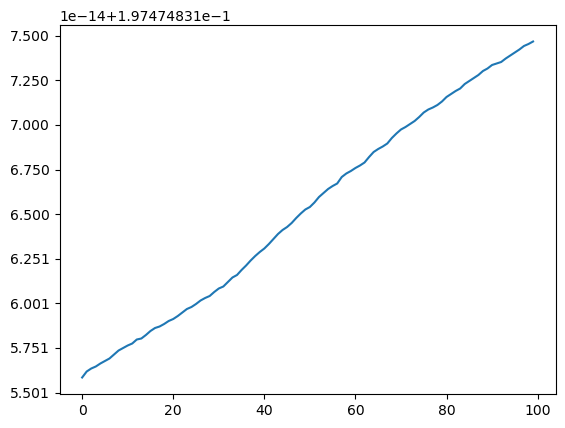

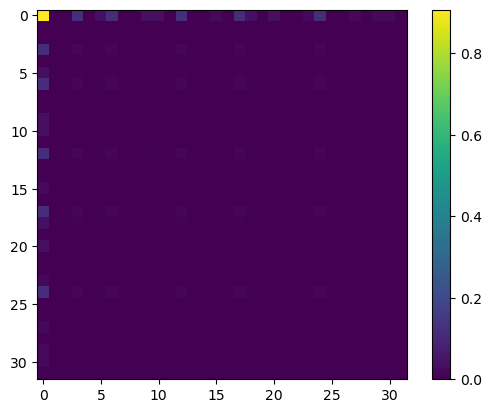

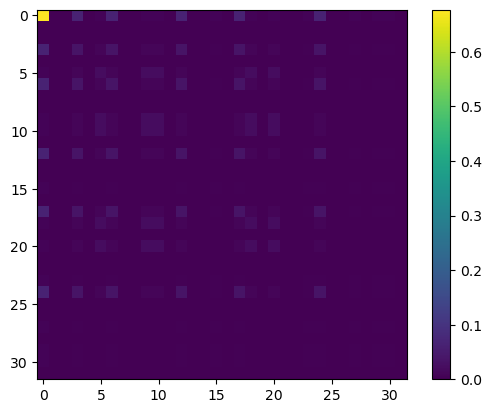

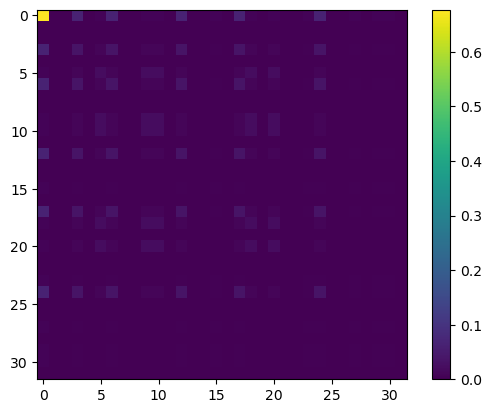

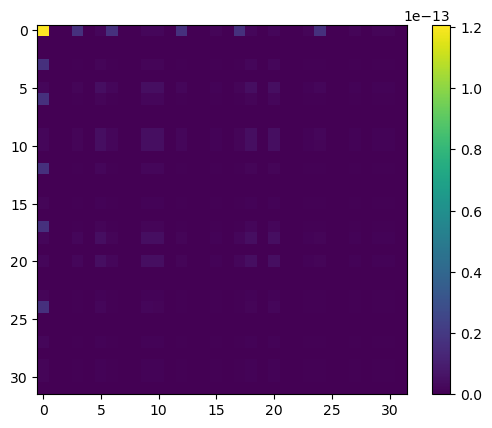

In [1185]:
T = 1
n_sites = 5
hop_x = -2.5
hop_3 = -.0
hop_4 = -.0
n_field_strengths = 100

fields = np.linspace(5,5,n_field_strengths)
fields[0] = -5

mags = np.zeros(n_field_strengths)
Mz = magnetization_Mz_operator(n_sites)

H_0 = create_H_chain(n_sites,fields[0],hop_x,hop_3=hop_3,hop_4=hop_4)
state_0 = thermal_state(H_0,T)
mags[0] = abs(expectation_value(Mz,state_0))

state_i = state_0.copy()

for i in trange(1,n_field_strengths):
    H_i = create_H_chain(n_sites,fields[i],hop_x,hop_3=hop_3,hop_4=hop_4)
    state_i = expectation_ensemble(H_i,state_i)
    mags[i] = abs(expectation_value(Mz,state_i))

H_n = create_H_chain(n_sites,fields[-1],hop_x)
state_n = expectation_ensemble(H_n,state_0)

plt.plot(mags)
#plt.plot(fields)
plt.show()

plt.imshow(abs(state_0)) #psi_0
plt.colorbar()
plt.show()

plt.imshow(abs(state_i)) #psi after iterative evolution
plt.colorbar()
plt.show()

plt.imshow(abs(state_n)) #psi after single-step transform
plt.colorbar()
plt.show()

plt.imshow( abs(state_i - state_n) ) #difference between iterative and single-step transform
plt.colorbar()
plt.show()


100%|██████████| 99/99 [00:00<00:00, 106.88it/s]


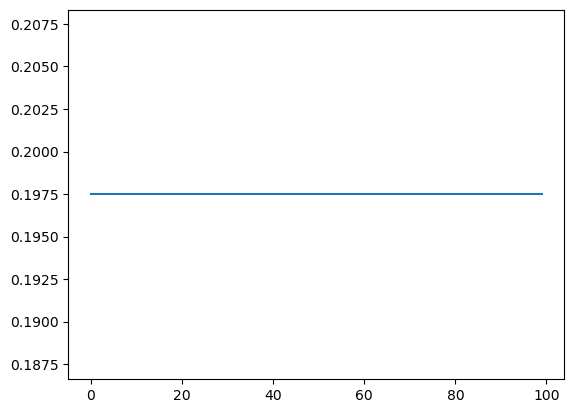

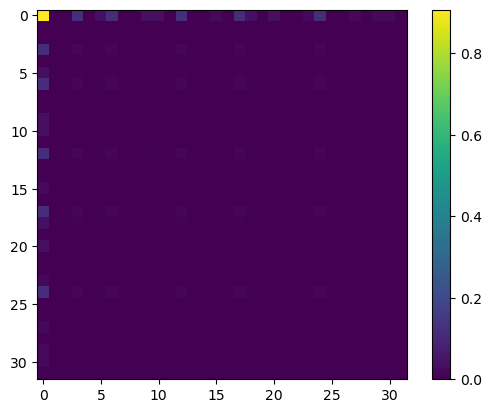

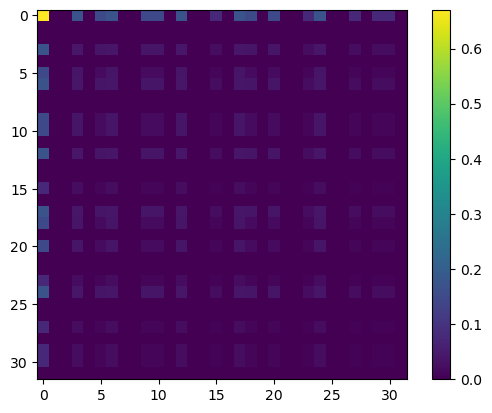

(0.9999999999999986+0j)
(0.999999999999999+0j)


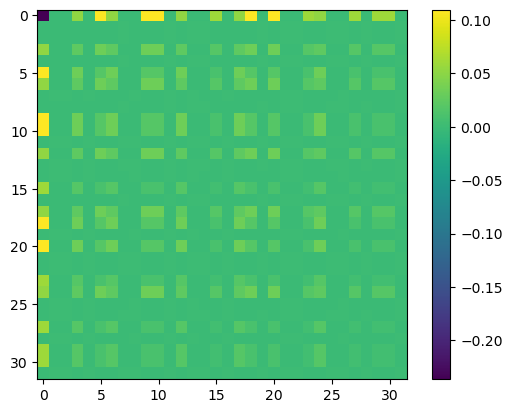

In [1186]:
T:float = 1
n_sites:int = 5
hop_x:float = -2.5
hop_y:float = -9
hop_3:float = -.0
hop_4:float= -.0
n_field_strengths:int = 100

dt = 0.002

fields = np.linspace(5,5,n_field_strengths)
fields[0] = -5

mags = np.zeros(n_field_strengths)
Mz = magnetization_Mz_operator(n_sites)

H_0 = create_H_chain(n_sites,fields[0],hop_x,hop_3=hop_3,hop_4=hop_4)
state_0 = thermal_state(H_0,T)
mags[0] = abs(expectation_value(Mz, state_0))
state_i = state_0.copy()


for i in trange(1,n_field_strengths):
    H_i = create_H_chain(n_sites,fields[i],hop_x,hop_y=hop_y,hop_3=hop_3,hop_4=hop_4).toarray()
    state_i = density_time_evolution(H_i,state_i,dt)
    mags[i] = abs(expectation_value(Mz, state_i))
    if np.trace(state_i) >= 1.1:
        print('trace growing! check dt!')
        break

plt.plot(mags)
plt.show()

plt.imshow(abs(state_0))
plt.colorbar()
plt.show()

plt.imshow(abs(state_i))
plt.colorbar()
plt.show()

print(np.trace(state_0))
print(np.trace(state_i))

plt.imshow(abs(state_i) - abs(state_0))
plt.colorbar()
plt.show()

In [1187]:
# Put at top of your script
import numpy as np
import scipy.linalg as sla
from itertools import product
from tqdm import trange
import math

# --- helper: n-fold Kronecker product using dense arrays ---
def kron_n(factors):
    """factor list -> full tensor product (dense numpy arrays)."""
    out = factors[0]
    for A in factors[1:]:
        out = np.kron(out, A)
    return out

# Pauli matrices (dense)
I2 = np.eye(2, dtype=np.complex128)
sx = np.array([[0,1],[1,0]], dtype=np.complex128)
sy = np.array([[0,-1j],[1j,0]], dtype=np.complex128)
sz = np.array([[1,0],[0,-1]], dtype=np.complex128)

def create_H_chain(n_sites:int, h:float,
                   hop_x:float=0., hop_y:float=0., hop_3:float=0., hop_4:float=0.,
                   hop_xy:float=0., bc:str='periodic'):
    """
    Build dense Hamiltonian (2^n x 2^n) with:
      field term:   h * sum_i sz_i
      xx term:      hop_x * sum_i sx_i sx_{i+1}
      yy term:      hop_y * sum_i sy_i sy_{i+1}
      xy mixed:     hop_xy * sum_i sx_i sy_{i+1} + sy_i sx_{i+1}  (if you want)
      3-body / 4-body: hop_3, hop_4 as requested (periodic only)
    """
    N = n_sites
    dim = 2**N
    H = np.zeros((dim, dim), dtype=np.complex128)

    # local field
    for i in range(N):
        factors = [I2]*N
        factors[i] = sz
        H += h * kron_n(factors)

    # nearest-neighbour terms
    max_i = N if bc == 'periodic' else N-1
    for i in range(max_i):
        j = (i+1) % N
        # xx
        factors = [I2]*N
        factors[i] = sx; factors[j] = sx
        H += hop_x * kron_n(factors)
        # yy
        factors = [I2]*N
        factors[i] = sy; factors[j] = sy
        H += hop_y * kron_n(factors)
        # mixed
        if abs(hop_xy) > 0:
            factors = [I2]*N
            factors[i] = sx; factors[j] = sy
            H += hop_xy * kron_n(factors)
            factors = [I2]*N
            factors[i] = sy; factors[j] = sx
            H += hop_xy * kron_n(factors)

    # 3-body and 4-body periodic terms (optional)
    if abs(hop_3) > 0 and N >= 3:
        for i in range(N if bc == 'periodic' else N-2):
            a,b,c = i, (i+1) % N, (i+2) % N
            factors = [I2]*N
            factors[a]=sx; factors[b]=sx; factors[c]=sx
            H += hop_3 * kron_n(factors)
    if abs(hop_4) > 0 and N >= 4:
        for i in range(N if bc == 'periodic' else N-3):
            a,b,c,d = i, (i+1) % N, (i+2) % N, (i+3) % N
            factors = [I2]*N
            factors[a]=sx; factors[b]=sx; factors[c]=sx; factors[d]=sx
            H += hop_4 * kron_n(factors)

    return H

def magnetization_Mz_operator(n_sites:int):
    """Return (1/N) * sum_i sigma_z^i (dense)."""
    N = n_sites
    dim = 2**N
    Mz = np.zeros((dim,dim), dtype=np.complex128)
    for i in range(N):
        factors = [I2]*N
        factors[i] = sz
        Mz += kron_n(factors)
    return Mz / float(N)

# --- thermal state (Gibbs) ---
def thermal_state(H: np.ndarray, T: float):
    """Return rho = exp(-H/T)/Z (dense).
       Numerically stable via subtracting min eigenvalue.
    """
    # diagonalize
    vals, vecs = sla.eigh(H)
    shift = vals.min()
    beta = 1.0 / T
    weights = np.exp(-beta * (vals - shift))
    Z = weights.sum()
    # build rho = V diag(weights) V^\dagger / Z
    rho = (vecs * weights) @ vecs.conj().T / Z
    # enforce Hermiticity and trace
    rho = (rho + rho.conj().T) / 2.0
    rho /= np.trace(rho)
    return rho

# --- diagonal projection (long-time dephased state in H basis) ---
def diagonal_project_in_basis(H: np.ndarray, rho: np.ndarray):
    vals, vecs = sla.eigh(H)
    rho_diag = np.zeros_like(rho)
    for i in range(len(vals)):
        psi = vecs[:, i:i+1]          # column vector
        P = psi @ psi.conj().T        # projector |psi><psi|
        rho_diag += P @ rho @ P
    # ensure hermitian, normalize
    rho_diag = (rho_diag + rho_diag.conj().T) / 2.0
    rho_diag /= np.trace(rho_diag)
    return rho_diag

# --- unitary evolution for time dt: exact step using expm ---
def unitary_evolve_rho(H: np.ndarray, rho: np.ndarray, dt: float):
    U = sla.expm(-1j * H * dt)
    rho_new = U @ rho @ U.conj().T
    # numerical cleanup
    rho_new = (rho_new + rho_new.conj().T) / 2.0
    return rho_new


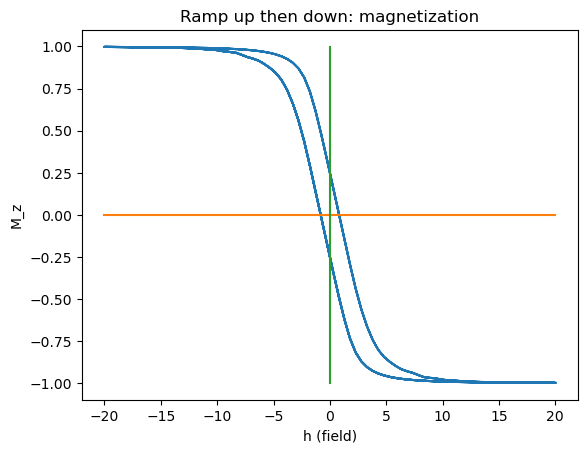

In [1374]:
# Parameters
n_sites = 5
T_bath = .01
hop_x = -2.0
hop_y = 0.0
hop_3 = 0.0
hop_4 = 0.0

field_max = 20

# Field ramp (up then down)
n_steps = 80


fields_init = np.linspace(field_max, -field_max, int(n_steps/1))
fields_up = np.linspace(-field_max, field_max, n_steps)
fields_down = np.linspace(field_max, -field_max, n_steps)
fields = np.concatenate([fields_init, fields_up, fields_down, fields_up, fields_down, fields_up, fields_down])

dt = 0.05   # unitary step time per field step (tunable)
alpha_relax = .2  # relaxation strength toward Gibbs at each step (0=no relaxation, 1=full thermalize instantly)

Mz_op = magnetization_Mz_operator(n_sites)

# initial state: thermal at field = fields[0]
H0 = create_H_chain(n_sites, fields[0], hop_x, hop_y, hop_3, hop_4)
rho = thermal_state(H0, T_bath)

mags = np.zeros(len(fields), dtype=float)

for idx, h in enumerate(fields):
    H = create_H_chain(n_sites, h, hop_x, hop_y, hop_3, hop_4)
    # OPTION A: unitary evolution for time dt with H
    rho = unitary_evolve_rho(H, rho, dt)

    # OPTION B (simple phenomenological relaxation toward Gibbs at same bath temp):
    # compute Gibbs at this H
    rho_th = thermal_state(H, T_bath)
    # relax partially: rho -> (1-alpha) rho + alpha * rho_th
    rho = (1.0 - alpha_relax) * rho + alpha_relax * rho_th
    # renormalize / enforce hermiticity
    rho = (rho + rho.conj().T) / 2.0
    rho /= np.trace(rho)

    mags[idx] = np.real(np.trace(rho @ Mz_op))

# now plot mags vs step (or vs field)
import matplotlib.pyplot as plt
plt.plot(fields, mags)#, marker='o')
plt.plot(fields, fields*0)
plt.plot(fields*0, mags)
plt.xlabel('h (field)')
plt.ylabel('M_z')
plt.title('Ramp up then down: magnetization')
plt.show()


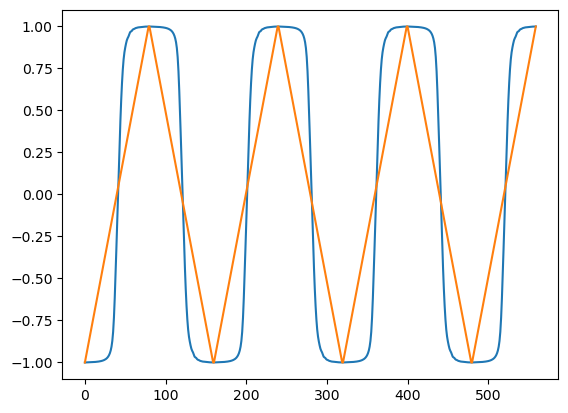

In [1375]:
plt.plot(mags/np.abs(mags).max())
plt.plot(-fields/np.abs(fields).max())

***Comparing dense vs. sparse eigensolvers***

Turns out sp.linalg.eigsh is on average slower than np.linalg.eigh! The numpy version also computes <i>all</i> of the eigenval/vec pairs, instead of being unable to capture the last 2 pairs.

On average, it appears that for small (but not trivial) numbers of qubits ($3\leq n\leq 8$), 

In [1005]:
n_sites = 3
k = 2**n_sites-2

test_sparse:bool = True
test_dense:bool = True


n_reps = 30

tic_chain = datetime.datetime.now()
H_chain = create_H_chain(n_sites,2,.5)

t_chain = float(f"{(datetime.datetime.now() - tic_chain).seconds}" + '.' + f"{(datetime.datetime.now() - tic_chain).microseconds}")
print(f"H creation t_elapsed: {t_chain:.3e}")

if test_sparse == True:
    tic_sparse = datetime.datetime.now()
    for i in range(n_reps):
        val, vec = spla.eigsh(H_chain,which='SA',k=k)
    t_sparse = float(f"{(datetime.datetime.now() - tic_sparse).seconds}" + '.' + f"{(datetime.datetime.now() - tic_sparse).microseconds}")/n_reps
    print(f"sparse eigensolver t_elapsed/rep: {t_sparse:.3e}")

if test_dense == True:
    tic_conv = datetime.datetime.now()
    H_arr = H_chain.toarray()
    t_conv = float(f"{(datetime.datetime.now() - tic_conv).seconds}" + '.' + f"{(datetime.datetime.now() - tic_conv).microseconds}")/n_reps
    print(f"sparse to dense conversion t_elapsed: {t_conv:.3e}")


    tic_dense = datetime.datetime.now()

    for i in range(n_reps):
        val, vec = np.linalg.eigh(H_arr)
    t_dense = float(f"{(datetime.datetime.now() - tic_dense).seconds}" + '.' + f"{(datetime.datetime.now() - tic_dense).microseconds}")/n_reps
    print(f"dense eigensolver t_elapsed/rep: {t_dense:.3e}")

if (test_sparse == True) and (test_dense == True):
    print(f't_sparse/t_dense: {t_sparse/t_dense:.3f}')


H creation t_elapsed: 4.378e-01
sparse eigensolver t_elapsed/rep: 1.411e-02
sparse to dense conversion t_elapsed: 4.000e-03
dense eigensolver t_elapsed/rep: 7.500e-03
t_sparse/t_dense: 1.882


In [1387]:
from scipy import constants

constants.k*1*2.64e18*1000000

36.4491336